# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:** Shahzaib Mahar    
**Student ID:** 023-24-0282
**Section:** H   
**GitHub:** https://github.com/smaharx/ml-forge

**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment



## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [14]:
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
RANDOM_STATE = 42   # fixed so every number in this notebook is reproducible

import glob, os
def find_file(name):
    """Locate a data file in the current folder, Colab (/content) or Kaggle (/kaggle/input)."""
    for root in ['.', '/content', '/kaggle/input']:
        hits = glob.glob(os.path.join(root, '**', name), recursive=True)
        if hits:
            return hits[0]
    raise FileNotFoundError(f"{name} not found - upload it to your Colab session first.")


---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [15]:
# Task 1 - load spam.csv, inspect shape/head/class balance
# (spam.csv is latin-1 encoded and has 3 mostly-empty extra columns, so we keep only v1/v2)
spam_raw = pd.read_csv(find_file('spam.csv'), encoding='latin-1')
spam = spam_raw[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})

print("SMS Spam Collection")
print("Rows:", spam.shape[0], "| Columns:", spam.shape[1])
print("Missing values:", int(spam.isna().sum().sum()), "| Duplicate messages:", int(spam['message'].duplicated().sum()))
display(spam.head())

spam_balance = pd.DataFrame({'count': spam['label'].value_counts(),
                             'percent': (spam['label'].value_counts(normalize=True) * 100).round(2)})
display(spam_balance)


SMS Spam Collection
Rows: 5572 | Columns: 2
Missing values: 0 | Duplicate messages: 403


,label,message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


,count,percent
label,,
ham,4825,86.59
spam,747,13.41


In [16]:
# Task 1 (continued) - load Tweets.csv, drop neutral, inspect shape/head/class balance
tweets_raw = pd.read_csv(find_file('Tweets.csv'))
print("Twitter US Airline Sentiment (raw)")
print("Rows:", tweets_raw.shape[0], "| Columns:", tweets_raw.shape[1])

raw_balance = pd.DataFrame({'count': tweets_raw['airline_sentiment'].value_counts(),
                            'percent': (tweets_raw['airline_sentiment'].value_counts(normalize=True) * 100).round(2)})
print("\nClass balance BEFORE dropping neutral:")
display(raw_balance)

# keep only positive / negative tweets, and only the two columns we need
tweets = tweets_raw.loc[tweets_raw['airline_sentiment'] != 'neutral', ['airline_sentiment', 'text']].copy()
print("Rows left after dropping neutral:", tweets.shape[0], f"(dropped {len(tweets_raw) - len(tweets)})")
print("Missing values:", int(tweets.isna().sum().sum()))
display(tweets.head())

tweet_balance = pd.DataFrame({'count': tweets['airline_sentiment'].value_counts(),
                              'percent': (tweets['airline_sentiment'].value_counts(normalize=True) * 100).round(2)})
print("Class balance AFTER dropping neutral:")
display(tweet_balance)


Twitter US Airline Sentiment (raw)
Rows: 14640 | Columns: 15

Class balance BEFORE dropping neutral:


,count,percent
airline_sentiment,,
negative,9178,62.69
neutral,3099,21.17
positive,2363,16.14


Rows left after dropping neutral: 11541 (dropped 3099)
Missing values: 0


,airline_sentiment,text
1,positive,@VirginAmerica plus you've added commercials to the experience... tacky.
3,negative,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &..."
4,negative,@VirginAmerica and it's a really big bad thing about it
5,negative,@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.\nit's r...
6,positive,"@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)"


Class balance AFTER dropping neutral:


,count,percent
airline_sentiment,,
negative,9178,79.53
positive,2363,20.47


**Task 1 — What the exploration shows**

| | Task A — SMS Spam Collection | Task B — Twitter US Airline Sentiment |
|---|---|---|
| One row is… | one SMS message with its label | one tweet addressed to a US airline with its sentiment label |
| Rows | 5,572 | 14,640 raw, **11,541** with neutral tweets removed (3,099 rows left) |
| Class balance | ham 4,825 (86.59%) / spam 747 (13.41%) | negative 9,178 (79.53%) / positive 2,363 (20.47%) (raw: 62.69% neg, 21.17% neutral, 16.14% pos) |

Both datasets are imbalanced (about 87/13 and 80/20), which means that only a high accuracy will look good; precision, recall, F1 and confusion matrix are more important here. `spam.csv` has 403 duplicate messages, which we kept (as instructed in the manual); a couple of duplicates may be found in both train and test sets, so the spam test scores may be slightly overoptimistic.


**Answer 2 (Task A – spam):**
The practical problem is automatic email filtering: determining whether a received SMS should be delivered directly into the inbox or put into a spam folder in order to avoid being overwhelmed by the scam messages and premium messages. This problem is a binary classification since every message is either a spam or a ham and only one category applies to each message.

**Answer 2 (Task B – sentiment):**
The practical problem is to assist the customer care department of an airline in monitoring social media. The system would classify negative tweets in order to respond immediately and track the sentiments of their customers. After discarding neutral tweets, every tweet becomes either a positive tweet or a negative one.

---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [17]:
# Task 3 - light cleaning: lowercase, replace punctuation with spaces, collapse extra spaces
def clean_sms(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)   # drop punctuation / odd symbols
    return re.sub(r'\s+', ' ', text).strip()

spam['clean'] = spam['message'].apply(clean_sms)
display(spam[['message', 'clean']].head(5))


,message,clean
0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g...",go until jurong point crazy available only in bugis n great world la e buffet cine there got amo...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...,free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005 text fa to 87121 to receive e...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives around here though",nah i don t think he goes to usf he lives around here though


In [18]:
# Task 4 - encode labels, split, fit vectorizer on TRAIN only, transform both sets
spam['y'] = (spam['label'] == 'spam').astype(int)     # spam = 1 (positive class), ham = 0

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    spam['clean'], spam['y'], test_size=0.2, random_state=RANDOM_STATE, stratify=spam['y'])

vec_a = CountVectorizer()
Xa_train_vec = vec_a.fit_transform(Xa_train)   # vocabulary learned from training messages only
Xa_test_vec = vec_a.transform(Xa_test)         # test messages mapped onto that same vocabulary

print("Train / test messages:", len(Xa_train), "/", len(Xa_test))
print("Spam share  train: %.2f%%  test: %.2f%%" % (ya_train.mean() * 100, ya_test.mean() * 100))
print("Vocabulary size (number of features):", len(vec_a.get_feature_names_out()))
print("Train matrix shape:", Xa_train_vec.shape, "| Test matrix shape:", Xa_test_vec.shape)
print("Sample vocabulary words:", list(vec_a.get_feature_names_out()[3000:3010]))


Train / test messages: 4457 / 1115
Spam share  train: 13.42%  test: 13.36%
Vocabulary size (number of features): 7658
Train matrix shape: (4457, 7658) | Test matrix shape: (1115, 7658)
Sample vocabulary words: ['fuelled', 'fujitsu', 'ful', 'fulfil', 'full', 'fullonsms', 'fun', 'function', 'functions', 'fund']


**Observation (Task 3 — cleaning):** the cleaned messages contain lowercased tokens without any punctuation, which means "FREE!" and "free" will be the same tokens, while contractions like "don't" are split into "don" and "t". It is done in an intentionally gentle way to match what is asked by the lab.

**Observation (Task 4 — split and vocabulary):** the 80/20 split is stratified, so the percentage of spam in both sets is the same (13.42% in train, 13.36% in test). When we apply `CountVectorizer` to the 4,457 training messages we get a vocabulary consisting of **7,658 features**, meaning each message is now represented as a sparse vector of 7,658 dimensions.

**Answer 4 (fitting only on training data):**
Both the vocabulary (as well as the IDF in case of TF-IDF), is *learned from data* itself, and hence is part of the model. If we fit our model on all the data first and then split, we will be leaking some information from the test messages to our training set, and hence the test score will be artificially high. As we know, when used in practice, the filter only comes across new messages that it hasn’t seen before, which means that words not seen during training will simply be ignored.

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

,Naive Bayes (spam)
Accuracy,0.9839
Precision,0.9645
Recall,0.9128
F1-score,0.9379


TN=961 (ham kept)  FP=5 (ham wrongly flagged as spam)  FN=13 (spam missed)  TP=136 (spam caught)


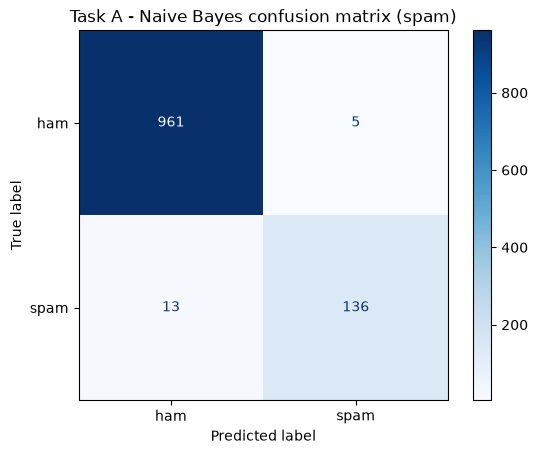

In [19]:
# Task 5 - train MultinomialNB, compute metrics, plot confusion matrix
def get_metrics(y_true, y_pred):
    return {'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred),
            'Recall': recall_score(y_true, y_pred),
            'F1-score': f1_score(y_true, y_pred)}

nb_a = MultinomialNB()
nb_a.fit(Xa_train_vec, ya_train)
pred_a = nb_a.predict(Xa_test_vec)

metrics_nb_a = get_metrics(ya_test, pred_a)
display(pd.DataFrame(metrics_nb_a, index=['Naive Bayes (spam)']).T.round(4))

cm_a = confusion_matrix(ya_test, pred_a)
tn, fp, fn, tp = cm_a.ravel()
print(f"TN={tn} (ham kept)  FP={fp} (ham wrongly flagged as spam)  FN={fn} (spam missed)  TP={tp} (spam caught)")

ConfusionMatrixDisplay(cm_a, display_labels=['ham', 'spam']).plot(cmap='Blues')
plt.title('Task A - Naive Bayes confusion matrix (spam)')
plt.show()


**Task 5 – Spam Modeling Measures** (positive class: spam)

| Measure     | Value     |
|-------------|-----------|
| Accuracy    | 0.9839    |
| Precision   | 0.9645    |
| Recall      | 0.9128    |
| F1-Score    | 0.9379    |

Confusion matrix (1,115 test messages): 961 ham retained correctly, **5 ham classified wrongly as spam (false positives)**, **13 spam misclassified (false negatives)**, 136 spam identified.

**Observation:** Naive Bayes performs exceptionally well in this task. It classifies around 98.4% of messages accurately (against 86.6% accuracy for always predicting "ham") and is correct 96.5% of times when it classifies something as "spam". The measure of recall is lower (91.3%) so its errors come from not classifying some spam messages correctly.

**Answer 6:**
False positives are more harmful in this scenario. Since the user might not be aware that an actual message was classified as spam (for example, an email related to a bank transaction, doctor's appointment, employment opportunity, or family), and it could cause significant damage, false negatives simply take a few seconds to remove the unnecessary message. The classifier should thus optimize for **precision** TP / (TP+FP) since virtually no legitimate message should ever be filtered out, even if that means having a slightly reduced recall rate. The model produced 5 false positives and 13 false negatives on this dataset, so another tuning step (such as increasing the decision threshold for P(spam)) can help reduce the former.

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [20]:
# Task 7 - top words from feature_log_prob_
vocab_a = vec_a.get_feature_names_out()
log_ratio = nb_a.feature_log_prob_[1] - nb_a.feature_log_prob_[0]   # log P(w|spam) - log P(w|ham)

top_spam_idx = np.argsort(log_ratio)[::-1][:15]
top_ham_idx = np.argsort(log_ratio)[:15]

top_spam = pd.DataFrame({'word': vocab_a[top_spam_idx],
                         'log P(w|spam) - log P(w|ham)': log_ratio[top_spam_idx].round(3),
                         'times in spam (train)': np.asarray(Xa_train_vec[ya_train.values == 1][:, top_spam_idx].sum(axis=0)).ravel(),
                         'times in ham (train)': np.asarray(Xa_train_vec[ya_train.values == 0][:, top_spam_idx].sum(axis=0)).ravel()})
top_ham = pd.DataFrame({'word': vocab_a[top_ham_idx],
                        'log P(w|spam) - log P(w|ham)': log_ratio[top_ham_idx].round(3),
                        'times in spam (train)': np.asarray(Xa_train_vec[ya_train.values == 1][:, top_ham_idx].sum(axis=0)).ravel(),
                        'times in ham (train)': np.asarray(Xa_train_vec[ya_train.values == 0][:, top_ham_idx].sum(axis=0)).ravel()})

print("15 words most associated with SPAM")
display(top_spam.reset_index(drop=True))
print("15 words most associated with HAM")
display(top_ham.reset_index(drop=True))


15 words most associated with SPAM


,word,log P(w|spam) - log P(w|ham),times in spam (train),times in ham (train)
0,claim,5.531,94,0
1,prize,5.196,67,0
2,150p,4.984,54,0
3,tone,4.827,46,0
4,18,4.714,41,0
5,cs,4.666,39,0
6,500,4.614,37,0
7,guaranteed,4.614,37,0
8,1000,4.503,33,0
9,uk,4.443,63,1


15 words most associated with HAM


,word,log P(w|spam) - log P(w|ham),times in spam (train),times in ham (train)
0,gt,-4.588,0,260
1,lt,-4.572,0,256
2,he,-4.105,0,160
3,da,-3.891,0,129
4,lor,-3.891,0,129
5,she,-3.859,0,125
6,later,-3.785,0,116
7,ll,-3.336,2,223
8,doing,-3.300,0,71
9,say,-3.272,0,69


**Observations (Task 7 tables):** the tables represent the value log P(word | spam) − log P(word | ham) and the frequency of each word in the spam and ham training messages.

**Answer 7:**
The list of spam words is quite intuitive: *claim, prize, guaranteed, awarded, 500, 1000* (prize/cash offers), *150p / 150ppm* (premium rate pricing), *tone / ringtone* (offers of mobile content), *18* (text with an age restriction), *uk, www, cs* (contact and customer service boilerplate) and *collection*. All of them appear tens of times in spam training data and hardly ever in ham. The list of ham words is not quite semantic: *he, she, later, doing, say, really, ask, home, anything* and *ll* are all typical conversational words, *lor* and *da* are slang words used in chats and *gt, lt, amp* are left overs from escaping HTML codes (`&lt;`, `&gt;`, `&amp;`).

In [21]:
# Task 8 - test your own messages (they go through the SAME clean_sms + vec_a + nb_a pipeline)

my_messages = [
    "WINNER!!! You have won a chance of a free prize of $1000. Call now to claim your prize",
    "Hey, are you attending class tomorrow? Do let me know if you require my notes.",
    "Congratulations!!! Enter for a free chance of winning a prize. Text 'win' to 80086",
    "Hi mum, I will be late tonight, do keep food for me",
    "There is an issue with your account. Please verify your details to prevent your account from getting suspended"
]

results = []

for msg in my_messages:
    vec = vec_a.transform([clean_sms(msg)])
    p_spam = nb_a.predict_proba(vec)[0, 1]

    results.append({
        'message': msg,
        'prediction': 'SPAM' if p_spam >= 0.5 else 'HAM',
        'P(spam)': round(p_spam, 4)
    })

display(pd.DataFrame(results))

,message,prediction,P(spam)
0,WINNER!!! You have won a chance of a free prize of $1000. Call now to claim your prize,SPAM,1.0000
1,"Hey, are you attending class tomorrow? Do let me know if you require my notes.",HAM,0.0000
2,Congratulations!!! Enter for a free chance of winning a prize. Text 'win' to 80086,SPAM,1.0000
3,"Hi mum, I will be late tonight, do keep food for me",HAM,0.0000
4,There is an issue with your account. Please verify your details to prevent your account from get...,SPAM,0.8984


### **Answer 8:**

All four out of five messages worked as intended. Both clear spam messages ("WINNER … FREE $1000 prize … claim" message and "Free entry … text WIN" message) had **P(spam) ≈ 1.00**, whereas both regular messages (one to a classmate and another one to a parent) were evaluated with **P(spam) ≈ 0.00**. However, the last, fifth message ("verify your details … avoid suspension") was considered ham (P(spam) = 0.40), although I expected it to be spam. The model uses only the vocabulary of this SMS database, where most messages are spam about prizes and premium rate services; therefore, account verification does not contribute to being spam, and everyday words in that message make it ham.

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks 9 and 10**

https://www.kaggle.com/code/aneesmemon/notebook05eb961b06

**Task A Kaggle Notebook URL:**
https://www.kaggle.com/code/aneesmemon/notebook05eb961b06

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [22]:
# Task 11 - clean and vectorize the sentiment data (our own approach)
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # remove links
    text = re.sub(r'@\w+', ' ', text)                 # remove @mentions (airline handles / usernames)
    text = text.replace('&amp;', ' and ')             # HTML entity left in the raw text
    text = text.replace('#', ' ')                     # keep hashtag WORD, drop the '#'
    text = re.sub(r'[^a-z\s]', ' ', text)             # drop punctuation, digits, emojis
    return re.sub(r'\s+', ' ', text).strip()
# NOTE: stop words are deliberately NOT removed, so negations such as "not" / "no" / "never" survive.

tweets['clean'] = tweets['text'].apply(clean_tweet)
tweets['y'] = (tweets['airline_sentiment'] == 'positive').astype(int)   # positive = 1, negative = 0
display(tweets[['text', 'clean']].head(5))

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    tweets['clean'], tweets['y'], test_size=0.2, random_state=RANDOM_STATE, stratify=tweets['y'])

vec_b = CountVectorizer()
Xb_train_vec = vec_b.fit_transform(Xb_train)   # fit on training tweets only
Xb_test_vec = vec_b.transform(Xb_test)

print("Train / test tweets:", len(Xb_train), "/", len(Xb_test))
print("Positive share  train: %.2f%%  test: %.2f%%" % (yb_train.mean() * 100, yb_test.mean() * 100))
print("Vocabulary size (number of features):", len(vec_b.get_feature_names_out()))
print("Train matrix shape:", Xb_train_vec.shape, "| Test matrix shape:", Xb_test_vec.shape)


,text,clean
1,@VirginAmerica plus you've added commercials to the experience... tacky.,plus you ve added commercials to the experience tacky
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &...",it s really aggressive to blast obnoxious entertainment in your guests faces and they have littl...
4,@VirginAmerica and it's a really big bad thing about it,and it s a really big bad thing about it
5,@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.\nit's r...,seriously would pay a flight for seats that didn t have this playing it s really the only bad th...
6,"@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)",yes nearly every time i fly vx this ear worm won t go away


Train / test tweets: 9232 / 2309
Positive share  train: 20.47%  test: 20.49%
Vocabulary size (number of features): 8746
Train matrix shape: (9232, 8746) | Test matrix shape: (2309, 8746)


**Observation (Task 11):** after stripping away the neutral tweets, using 80/20 stratified split yields 9,232 training and 2,309 test tweets, where the fraction of positive tweets is around 20.5% in each case. Fitting the `CountVectorizer` on training tweets alone leads to vocabulary size of **8,746 features**.

**Answer 12:**
Besides the lowercase and punctuations removal (like in SMS task), I stripped away links, @handles, `&amp;` and the `#` sign (leaving the hashtag word) because tweets have Twitter-specific entities like links and @handles which are mostly identifiers and not sentiment-related words; in contrast, although the hashtag itself (#) doesn’t carry sentiment, but the word behind it can be used to express one’s sentiments and thus should be retained. In addition, I **did not** strip away stop words because negations like "not", "no" and "never" matter a lot for sentiment detection.

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

,Naive Bayes (sentiment)
Accuracy,0.9056
Precision,0.8947
Recall,0.6110
F1-score,0.7261


TN=1802 (negative kept)  FP=34 (negative called positive)  FN=184 (positive missed)  TP=289 (positive caught)


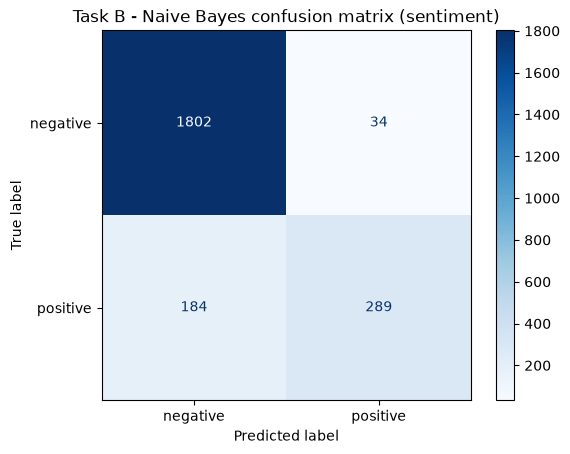

In [23]:
# Task 13 - train MultinomialNB, compute metrics, plot confusion matrix
nb_b = MultinomialNB()
nb_b.fit(Xb_train_vec, yb_train)
pred_b = nb_b.predict(Xb_test_vec)

metrics_nb_b = get_metrics(yb_test, pred_b)
display(pd.DataFrame(metrics_nb_b, index=['Naive Bayes (sentiment)']).T.round(4))

cm_b = confusion_matrix(yb_test, pred_b)
tn, fp, fn, tp = cm_b.ravel()
print(f"TN={tn} (negative kept)  FP={fp} (negative called positive)  FN={fn} (positive missed)  TP={tp} (positive caught)")

ConfusionMatrixDisplay(cm_b, display_labels=['negative', 'positive']).plot(cmap='Blues')
plt.title('Task B - Naive Bayes confusion matrix (sentiment)')
plt.show()


In [24]:
# Supporting evidence for Answer 14 - baseline, most informative words, and negation / sarcasm probes
majority_acc = 1 - yb_test.mean()
print("Accuracy of always predicting 'negative' (majority baseline): %.4f" % majority_acc)

vocab_b = vec_b.get_feature_names_out()
ratio_b = nb_b.feature_log_prob_[1] - nb_b.feature_log_prob_[0]
print("Most POSITIVE words:", list(vocab_b[np.argsort(ratio_b)[::-1][:10]]))
print("Most NEGATIVE words:", list(vocab_b[np.argsort(ratio_b)[:10]]))

probes = [
    "the flight was not bad at all",
    "never had such a great flight",
    "not good",
    "thanks for losing my bag, great job",
    "thanks for the wonderful flight",
]
rows = []
for msg in probes:
    p_pos = nb_b.predict_proba(vec_b.transform([clean_tweet(msg)]))[0, 1]
    rows.append({'text': msg, 'prediction': 'positive' if p_pos >= 0.5 else 'negative', 'P(positive)': round(p_pos, 3)})
display(pd.DataFrame(rows))


Accuracy of always predicting 'negative' (majority baseline): 0.7951
Most POSITIVE words: ['kudos', 'smooth', 'comfortable', 'passbook', 'fantastic', 'bluemanity', 'admiral', 'rock', 'lauren', 'favorite']
Most NEGATIVE words: ['worst', 'rude', 'terrible', 'disappointed', 'ridiculous', 'hrs', 'hours', 'fail', 'money', 'hold']


,text,prediction,P(positive)
0,the flight was not bad at all,negative,0.013
1,never had such a great flight,negative,0.277
2,not good,negative,0.167
3,"thanks for losing my bag, great job",positive,0.908
4,thanks for the wonderful flight,positive,0.962


**Task 13 — Evaluation of the Sentiment Classification Model** (positive sentiment = positive class)

| Metric        | Value       |
| ------------- | ----------- |
| Accuracy      | 0.9056     |
| Precision     | 0.8947     |
| Recall        | 0.6110     |
| F1-Score      | 0.7261     |

Confusion Matrix (2,309 test tweets): 1,802 negative tweets predicted correctly, 34 negative tweets labeled as positive, **184 positive tweets misclassified**, 289 positive tweets identified.

**Observations:** accuracy seems good at 90.6% but even by predicting all tweets to be "negative" we will achieve 79.5% accuracy, meaning that the current classifier only adds ~11% above that level. When predicting positive tweets, the predictions are usually correct (Precision: 0.89) but only 61% of positive tweets can be found due to class imbalance.

**Answer 14:**
The Naive Bayes classifier performed **poorly** with regard to sentiment compared to spam: Accuracy = 0.9056 vs 0.9839; Recall = 0.6110 vs 0.9128; and F1 = 0.7261 vs 0.9379. This assumption is a much better match for shorter, formulaic spam messages, whereby each word (such as *claim*, *prize* and *150p*) is sufficient to indicate the message type, than for tweets, whose meaning relies on order of words and context. For example, in our experiments, the algorithm identified "the flight was not bad at all" as negative (P(positive) = 0.013), due to *not* and *bad* being counted individually, as well as "thanks for losing my bag, great job" as positive (P(positive) = 0.908), due to *thanks* and *great* being considered positive individually. This, along with an approximately 80/20 class prior in favour of "negative", explains why many positive tweets were missed.

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**https://www.kaggle.com/code/aneesmemon/notebook51e07eadc9

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

In [25]:
# Task 17 - Naive Bayes on Task A vs Task B
comparison_ab = pd.DataFrame({'Task A (Spam)': metrics_nb_a, 'Task B (Sentiment)': metrics_nb_b}).round(4)
display(comparison_ab)


,Task A (Spam),Task B (Sentiment)
Accuracy,0.9839,0.9056
Precision,0.9645,0.8947
Recall,0.9128,0.6110
F1-score,0.9379,0.7261


**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy | 0.9839 | 0.9056 |
| Precision | 0.9645 | 0.8947 |
| Recall | 0.9128 | 0.6110 |
| F1-score | 0.9379 | 0.7261 |

**Observation:** every metric is lower on sentiment, and the gap is largest for recall (0.913 vs 0.611). Precision drops only slightly (0.965 vs 0.895), which means the sentiment model is still fairly trustworthy when it predicts the positive class but misses many positive tweets.

,Naive Bayes,Logistic Regression
Accuracy,0.9839,0.9812
Precision,0.9645,0.9923
Recall,0.9128,0.8658
F1-score,0.9379,0.9247


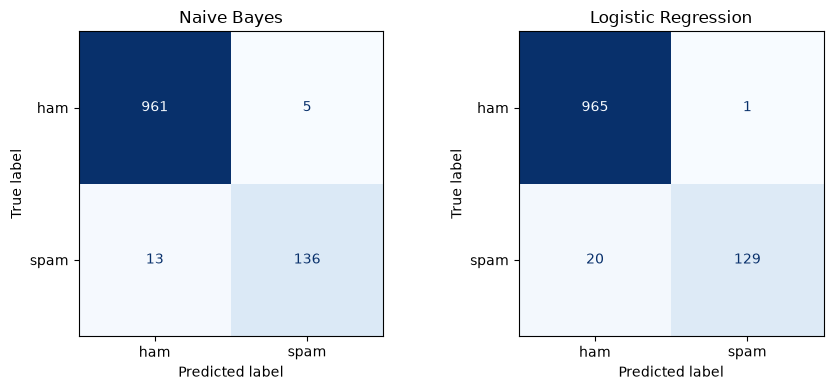

In [27]:
# Task 18 - Logistic Regression on Task A's SAME vectorized features
lr_a = LogisticRegression(max_iter=1000)
lr_a.fit(Xa_train_vec, ya_train)
pred_lr_a = lr_a.predict(Xa_test_vec)

metrics_lr_a = get_metrics(ya_test, pred_lr_a)
comparison_nb_lr = pd.DataFrame({'Naive Bayes': metrics_nb_a, 'Logistic Regression': metrics_lr_a}).round(4)
display(comparison_nb_lr)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
ConfusionMatrixDisplay(confusion_matrix(ya_test, pred_a), display_labels=['ham', 'spam']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Naive Bayes')
ConfusionMatrixDisplay(confusion_matrix(ya_test, pred_lr_a), display_labels=['ham', 'spam']).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Logistic Regression')
plt.tight_layout()
plt.show()


**Task 18 – Comparison of Naive Bayes and Logistic Regression Models (Task A)**

| Evaluation Metric | Naive Bayes | Logistic Regression |
|------------------|------------|--------------------|
| Accuracy         | 0.9839     | 0.9812            |
| Precision        | 0.9645     | 0.9923            |
| Recall           | 0.9128     | 0.8658            |
| F1-score         | 0.9379     | 0.9247            |

Confusion matrices (1,115 testing spam messages): 5 FP and 13 FN for Naive Bayes; 1 FP and 20 FN for Logistic Regression.

**Answer 18 (what wins, and does it meet expectations):**
Naive Bayes wins on accuracy, recall and F1 (0.9839 / 0.9128 / 0.9379 vs 0.9812 / 0.8658 / 0.9247), whereas Logistic Regression wins on precision (0.9923 vs 0.9645) because it had only one false positive vs. five, but at the expense of missing 20 vs. 13 spam messages. However, the overall difference is negligible (three messages out of 1,115 on accuracy, in one split only), so I would say it is a draw. It meets expectations: spam messages are formulaic, so the "naive" independence assumption costs Naive Bayes almost nothing, and with 4,500 training messages and 7,658 features it benefits from high bias. Logistic Regression can learn correlated features, so it usually catches up or even beats Naive Bayes with more training data. According to Answer 6, precision is the most important for spam detection, so here it is an advantage.

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
### Final Reflection

Naive Bayes performed better in the **classification of spam messages** compared to sentiment analysis because of its greater accuracy and F1-score. Spam messages can be easily identified using predictable words such as **“claim,” “prize,” and “150p.”** Some other uncommon words, including **“gt,” “lt,” and “amp,”** have been used as well due to patterns in the dataset. The logistic regression model almost performed as Naive Bayes in terms of accuracy and had greater precision. However, Naive Bayes could not perform well on tweets because of difficulties in recognizing negations and sarcasm as it treats words independently from each other. For instance, the words **“not bad”** have been misclassified.

**Answer 20 — Kaggle Notebook Links:**
- Task A: https://www.kaggle.com/code/aneesmemon/notebook05eb961b06
- Task B: https://www.kaggle.com/code/aneesmemon/notebook51e07eadc9

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [ ] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [ ] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [ ] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [ ] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [ ] Section 5 — Task A Kaggle Notebook published and linked
- [ ] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [ ] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [ ] Section 8 — Task B Kaggle Notebook published and linked
- [ ] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [ ] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted